In [1]:
import os
import sys

In [2]:
import json

with open("client_ip.json", "r") as f:
    client_ip = json.load(f)

In [3]:
import tensorflow as tf

2025-06-19 13:08:37.648326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750352917.666054 2818668 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750352917.671499 2818668 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750352917.687775 2818668 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750352917.687788 2818668 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750352917.687791 2818668 computation_placer.cc:177] computation placer alr

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/nas/longleaf/rhel8/apps/anaconda/2023.03.ood/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/nas/longleaf/rhel8/apps/anaconda/2023.03.ood/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/nas/longleaf/rhel8/apps/anaconda/2023.03.ood/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/nas/longleaf/rhel8/apps/anaconda/2023.03.ood/lib/python3.10/site-packag

AttributeError: _ARRAY_API not found

In [4]:
print(tf.__version__)

2.19.0


In [5]:
module_path = os.path.abspath('../method/preprocess.py')
module_dir = os.path.dirname(module_path)
if module_dir not in sys.path:
    sys.path.append(module_dir)
module_path = os.path.abspath('../transformation/transformation.py')
module_dir = os.path.dirname(module_path)
if module_dir not in sys.path:
    sys.path.append(module_dir)

In [6]:
from preprocess import train_traffic_csv_converter
from preprocess import test_traffic_csv_converter
from preprocess import iterate_over_files_in_directory

In [7]:
batch_size = 128
features = 40
input_shape = (features,2)

In [8]:
import matplotlib.pyplot as plt
import numpy as np
WINDOW=40
def lstm_vector(ts1,sizes1,ts2,sizes2,s_port,d_port,voip=False):
    #determine direction
    if voip:
        src_ts = ts1
        src_sizes = sizes1
        dst_ts = ts2
        dst_sizes = sizes2
        src_port = s_port
        dst_port = d_port
    else:
        if ts1[0]<ts2[0]:
            src_ts = ts1
            src_sizes = sizes1
            dst_ts = ts2
            dst_sizes = sizes2
            src_port = s_port
            dst_port = d_port
        else:
            src_ts = ts2
            src_sizes = sizes2
            dst_ts = ts1
            dst_sizes = sizes1
            src_port = d_port
            dst_port = s_port
    array = []
    j = 0 #src
    k = 0 #dst
    min_val = min(src_ts[0],dst_ts[0])
    length = len(src_ts)+len(dst_ts)
    for i in range(40):
        if j>=len(src_ts) and k>=len(dst_ts):
            break
        if j>=len(src_ts):
            array.append([round(dst_ts[k]-min_val,6),dst_sizes[k],dst_port,src_port,1])
            k+=1
        elif k >= len(dst_ts):
            array.append([round(src_ts[j]-min_val,6),src_sizes[j],src_port,dst_port,0]) 
            j+=1
        elif src_ts[j]<=dst_ts[k]:
            array.append([round(src_ts[j]-min_val,6),src_sizes[j],src_port,dst_port,0]) 
            j+=1
        else:
            array.append([round(dst_ts[k]-min_val,6),dst_sizes[k],dst_port,src_port,1])
            k+=1
    # for i in range(WINDOW-length):
    #      array.append([0,0])
    array = np.array(array)
    X = array.reshape(-1,5)
    return X

In [9]:
WINDOW=50
def seq_50(ts1,sizes1,ts2,sizes2,s_port,d_port):
    #determine direction
    if ts1[0]<ts2[0]:
        src_ts = ts1
        src_sizes = sizes1
        dst_ts = ts2
        dst_sizes = sizes2
        src_port = s_port
        dst_port = d_port
    else:
        src_ts = ts2
        src_sizes = sizes2
        dst_ts = ts1
        dst_sizes = sizes1
        src_port = d_port
        dst_port = s_port
    array = []
    j = 0 #src
    k = 0 #dst
    min_val = min(src_ts[0],dst_ts[0])
    for i in range(WINDOW):
        if j>=len(src_ts) and k>=len(dst_ts):
            break
        if j>=len(src_ts):
            array.append([round(dst_ts[k]-min_val,6),dst_sizes[k],dst_port,src_port,1])
            k+=1
        elif k >= len(dst_ts):
            array.append([round(src_ts[j]-min_val,6),src_sizes[j],src_port,dst_port,0]) 
            j+=1
        elif src_ts[j]<=dst_ts[k]:
            array.append([round(src_ts[j]-min_val,6),src_sizes[j],src_port,dst_port,0]) 
            j+=1
        else:
            array.append([round(dst_ts[k]-min_val,6),dst_sizes[k],dst_port,src_port,1])
            k+=1
    for i in range(WINDOW-len(array)):
         array.append([0,0,0,0,0])
    array = np.array(array)
    X = array.reshape(-1,5)
    return X

In [10]:
def check_strings_in_classname(classname):
    keywords = {
    "web": 0, "video": 1, "social": 2, "email": 3,"voip":4,"chat":5,"gaming":6,"docs":7
    }
    for keyword in keywords:
        if keyword in classname:
            return keywords[keyword] 
    return None

In [11]:
# check_path = os.path.join(checkpoint_dir, MODEL_NAME + 'pseudo_labeled_binary_lstm_acc.weights.h5')
# pipeline.named_steps['model'].load_weights(check_path) 

In [12]:
X_train = []
y_train = []
voip = []
gaming = []
web = []
video = []
social = []
email = []
doc = []
microsoft = []
chat = []
background = []

In [13]:
path2 = os.path.abspath('..')

In [14]:
import os
import csv
import tensorflow as tf

folder_path = path2+"/labeled_train"

In [15]:
import json
def traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes,s_port,d_port = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        src_port,dst_port = s_port,d_port
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,src_port,dst_port,True)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes,src_port,dst_port)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,src_port,dst_port)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes,src_port,dst_port)
                if "voip" in file_path and class_name == "voip":
                    voip.append(v)
                    y_train.append(7)
                elif "gaming" in file_path:
                    gaming.append(v)
                    y_train.append(8)
                elif class_name == "web":
                    web.append(v)
                    y_train.append(0)
                elif class_name == "video":
                    video.append(v)
                    y_train.append(1)
                elif class_name == "social":
                    social.append(v)
                    y_train.append(2)
                elif class_name == "email":
                    email.append(v)
                    y_train.append(3)
                elif class_name == "doc":
                    doc.append(v)
                    y_train.append(4)
                elif class_name == "microsoft":
                    microsoft.append(v)
                    y_train.append(5)
                elif class_name == "chat":
                    chat.append(v)
                    y_train.append(6)
                else: #background_flow
                    background.append(v)
                    y_train.append(9)
                X_train.append(x)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes,src_port,dst_port)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                src_port = value[2]
                dst_port = value[3]
                if key[0] in client_ip:
                    sizes = value[1][:40]
                else:
                    sizes = -value[1][:40]
                s_port = np.repeat(src_port,  40) 
                d_port = np.repeat(dst_port,  40) 
                zeros = np.zeros(40)  
                
                v = np.column_stack([ts, sizes,s_port,d_port,zeros])
                X_train.append(v)
                if class_val[key] == "voip": #if the flow is unique
                    y_train.append(7)
                else:
                    y_train.append(9) #if the flow is background
                
                ts = value[0][:50]
                if key[0] in client_ip:
                    sizes = value[1][:50]
                else:
                    sizes = -value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                s_port = np.repeat(src_port,  50)  
                d_port = np.repeat(dst_port,  50)   
                zeros = np.zeros(50)  
                
                v = np.column_stack([ts, sizes,s_port,d_port,zeros])
                if class_val[key] == "voip":
                    voip.append(v)
            elif "gaming" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                src_port =value[2]
                dst_port = value[3]
                s_port = np.repeat(src_port,  40)
                d_port = np.repeat(dst_port,  40)  
                zeros = np.zeros(40)
                
                v = np.column_stack([ts, sizes,s_port,d_port,zeros])
                X_train.append(v)
                y_train.append(8)
                
                ts = value[0][:50]
                sizes = value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                s_port = np.repeat(src_port,  50)  
                d_port = np.repeat(dst_port,  50)  
                zeros = np.zeros(50)
                v = np.column_stack([ts, sizes,s_port,d_port,zeros])
                gaming.append(v)
            
            
    return X_train, y_train
def iterate_over_files_in_directory(directory):
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):  # You can adjust the file extension if needed
            file_path = os.path.join(directory, file_name)
            yield file_path


In [24]:
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = traffic_csv_converter(file_path)
        X_train.extend(X)
        y_train.extend(y)

In [25]:
import numpy as np

In [26]:
X_dataset = np.array(X_train)

In [27]:
y_dataset = np.array(y_train)

In [28]:
from collections import Counter
counter = Counter(y_dataset)
counts = [counter.get(i, 0) for i in range(10)]

In [29]:
max_val = max(counts)

In [30]:
max_val

24545

In [31]:
counts

[2697, 466, 792, 113, 116, 239, 54, 289, 1006, 24545]

In [16]:
def translation(X):
    arrival_times = X
    n,time_steps,features = arrival_times.shape
    for i in range(n):
        threshold_indices = [2,4,6,8,10] 
        max_n =np.random.choice(threshold_indices) 
        n = np.random.randint(1, max_n + 1)  # Shift 1 to `max_n` packets
        t = np.random.randint(0, 40) 
        direction = np.random.choice(['left', 'right'])
        if direction == 'left':
            total_length = arrival_times.shape[1]
            start_index = t-n
            if start_index < 0: 
                valid_portion = arrival_times[i, t - start_index:50]
                assigned_value = valid_portion.shape[0]
                arrival_times[i, 0:assigned_value] = valid_portion
                arrival_times[i, assigned_value+1:] = 0 
            else:
                valid_portion = arrival_times[i, t:(50)]
                assigned_value = arrival_times[i, start_index:50].shape
                zeros = np.zeros((assigned_value[0]-valid_portion.shape[0],5))
                arrival_times[i, start_index:50] = np.concatenate((valid_portion, zeros))  # bounded to the right by 50
            
        else:
            t_val = arrival_times[i, t] 
            last_index = min(t + n, 40) 
            first_val = min(last_index + n, 40)  
            num_to_shift = last_index - t  
            available_space = 40 - first_val 
            if num_to_shift > 0:
                shift_amount = min(num_to_shift, available_space)
                arrival_times[i, first_val:first_val + shift_amount] = arrival_times[i, t:t + shift_amount]
            arrival_times[i, t:last_index] = t_val
    return arrival_times

In [33]:
voip = np.array(voip)
gaming = np.array(gaming)
web = np.array(web)
video = np.array(video)
social = np.array(social)
email = np.array(email)
doc = np.array(doc)
microsoft = np.array(microsoft)
chat = np.array(chat)
background = np.array(background)

In [34]:
for i in range(9):
    if i == 0:
        sample = web
    elif i == 1:
        sample = video
    elif i == 2:
        sample = social
    elif i == 3:
        sample = email
    elif i == 4:
        sample = doc
    elif i == 5:
        sample = microsoft
    elif i == 6:
        sample = chat
    elif i == 7:
        sample = voip
    elif i == 8:
        sample = gaming
    indices = tf.range(sample.shape[0])
    value = len(sample)
    sampled_indices = np.random.choice(indices, max_val-value, replace=True)
    sampled_X = sample[sampled_indices]
    augmented = translation(sampled_X)
    augmented = augmented[:, :40, :]
    X_dataset = np.vstack((X_dataset,augmented))
    y = np.array([i]*(max_val-value))
    y_dataset = np.concatenate((y_dataset,y))

W0000 00:00:1750272071.253178 1110031 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [47]:
# X_train = np.load('X_train.npy')
# y_train = np.load('y_train.npy')
# X_val = np.load('X_val.npy')
# y_val = np.load('y_val.npy')

In [35]:
from keras.utils import to_categorical

In [36]:
X_dataset = np.array(X_dataset)
y_dataset = np.array(y_dataset)

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_dataset, y_dataset, test_size=0.2, random_state=42)

In [39]:
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)

In [40]:
y_train = to_categorical(y_train, num_classes=10)
y_val = to_categorical(y_val, num_classes=10)

In [17]:
input_shape = (40,5)

In [18]:
num_classes = 10

In [19]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.callbacks import TensorBoard, ModelCheckpoint
from keras.models import Sequential
from tensorflow.keras.models import Model
from keras.layers import Concatenate,RepeatVector,GlobalAveragePooling1D,Reshape,MaxPooling2D,ReLU,Input,InputLayer,Conv1D, MaxPooling1D, Flatten, Dense, Dropout,LSTM,BatchNormalization,Bidirectional,LayerNormalization
from keras import backend as K
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from keras.metrics import top_k_categorical_accuracy
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K
path = os.path.abspath('')


def precision(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def recall(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = recall(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec))

# def top_2_categorical_accuracy(y_true, y_pred):
#     return top_k_categorical_accuracy(y_true, y_pred, k=2)

# Custom transformer to transpose data

# Set the ratio for the train-test split


# Create a scikit-learn pipeline
pipeline = Sequential([
    InputLayer(input_shape=input_shape),            # e.g. (40,5)
    Bidirectional(LSTM(128, return_sequences=True)),
    LayerNormalization(),
    Bidirectional(LSTM(64, return_sequences=False)),
    LayerNormalization(),
    Dense(64, activation='gelu'),
    Dense(num_classes, activation='softmax')
])


# Set up callbacks
checkpoint_dir = os.path.abspath('')+"/tensorboard"
log_dir = os.path.abspath('') + "/log"
MODEL_NAME = "checkpoint"
check_path = os.path.join(checkpoint_dir, MODEL_NAME + '5_lstm_loss.weights.h5')
tensorboard = TensorBoard(log_dir='./Graph', histogram_freq=1, write_graph=True,
                          write_images=True)
checkpointer_loss = ModelCheckpoint(filepath=check_path, verbose=1, save_best_only=True,
                                     save_weights_only=True)
checkpointer_acc = ModelCheckpoint(monitor='val_f1_score', filepath= os.path.join(checkpoint_dir, MODEL_NAME + '5_lstm_acc.weights.h5'), verbose=1,
                                    save_best_only=True, save_weights_only=True,mode='max')
tensorboard.set_model(pipeline)

early_stopping = EarlyStopping(monitor='val_f1_score', patience=50, restore_best_weights=True,mode='max')



/nas/longleaf/home/paulchoi/.local/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
W0000 00:00:1750352944.689003 2818668 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [20]:
pipeline.compile(loss='categorical_crossentropy',
                                      optimizer='adam',
                                      metrics=['accuracy', f1_score, precision, recall])

In [ ]:
history = pipeline.fit(X_train, y_train, epochs=500, batch_size=batch_size, callbacks=[early_stopping,tensorboard, checkpointer_loss, checkpointer_acc],
         validation_data=(X_val, y_val))

Epoch 1/500
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.4392 - f1_score: nan - loss: 1.5165 - precision: 0.7934 - recall: 0.2310
Epoch 1: val_loss improved from inf to 1.01902, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpoint5_lstm_loss.weights.h5

Epoch 1: val_f1_score improved from -inf to 0.60111, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpoint5_lstm_acc.weights.h5
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 335s 215ms/step - accuracy: 0.4393 - f1_score: nan - loss: 1.5163 - precision: 0.7934 - recall: 0.2310 - val_accuracy: 0.6282 - val_f1_score: 0.6011 - val_loss: 1.0190 - val_precision: 0.7613 - val_recall: 0.4973
Epoch 2/500
1535/1535 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.6577 - f1_score: 0.6320 - loss: 0.9503 - precision: 0.7933 - recall: 0.5265
Epoch 2: val_loss improved from 1.01902 to 0.82570, saving model to /nas/longleaf/home/paulchoi/2stage/tensorboard/checkpoint5_lstm_loss.weights.h5

Epoch 2: val_f1_score i

In [21]:
# model = pipeline.named_steps['model']
# model.build(input_shape=(None, 50, 2)) 

In [21]:
from tensorflow.keras import Input
check_path = os.path.join(checkpoint_dir, MODEL_NAME + '5_lstm_acc.weights.h5')
input_shape = (50, 2)

# _ = pipeline.named_steps['model']( Input(shape=input_shape) )

# 2) Now that all weights exist, load them
pipeline.load_weights(check_path)

# 3) (Optional) verif

/nas/longleaf/home/paulchoi/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [22]:
X_test = []
y_test = []

In [23]:
import csv
def test_traffic_csv_converter(file_path):
    X_train = []
    y_train = []
    with open(file_path, 'r') as csv_file:
        reader = csv.reader(csv_file)
        filename = os.path.splitext(os.path.basename(file_path))[0]
        flow_val = {}
        class_val = {}
        paired_keys = set()
        for i, row in enumerate(reader):
            class_name = row[0]
            src_ip = row[1]
            src_port = row[2]
            dst_ip = row[3]
            dst_port = row[4]
            length = int(row[7])
            ts = np.array(row[8:8+length], dtype=float)
            sizes = np.array(row[9+length:], dtype=int)
            key = (src_ip, src_port, dst_ip, dst_port)
            reverse_key = (dst_ip, dst_port, src_ip, src_port)
            if reverse_key in flow_val:
                # Found the reverse flow
                opposite_ts, opposite_sizes,s_port,d_port = flow_val.pop(reverse_key)
                paired_keys.add(key)
                paired_keys.add(reverse_key)
                if len(opposite_ts) + len(ts) < 40: #flow too small
                    continue
                if "voip" in file_path and class_name =="voip":
                    if reverse_key[0] in client_ip:
                        src_ts, src_sizes = opposite_ts, opposite_sizes
                        src_port,dst_port = s_port,d_port
                        dst_ts, dst_sizes = ts, sizes
                    else:
                        src_ts, src_sizes = ts, sizes
                        dst_ts, dst_sizes = opposite_ts, opposite_sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,src_port,dst_port,True)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes,src_port,dst_port)
                else:
                    src_ts, src_sizes = opposite_ts, opposite_sizes
                    dst_ts, dst_sizes = ts, sizes
                    x = lstm_vector(src_ts, src_sizes, dst_ts, dst_sizes,src_port,dst_port)
                    v = seq_50(src_ts, src_sizes, dst_ts, dst_sizes,src_port,dst_port)
                if "voip" in file_path and class_name == "voip":
                    voip.append(v)
                    y_train.append(7)
                elif "gaming" in file_path:
                    gaming.append(v)
                    y_train.append(8)
                elif class_name == "web":
                    web.append(v)
                    y_train.append(0)
                elif class_name == "video":
                    video.append(v)
                    y_train.append(1)
                elif class_name == "social":
                    social.append(v)
                    y_train.append(2)
                elif class_name == "email":
                    email.append(v)
                    y_train.append(3)
                elif class_name == "doc":
                    doc.append(v)
                    y_train.append(4)
                elif class_name == "microsoft":
                    microsoft.append(v)
                    y_train.append(5)
                elif class_name == "chat":
                    chat.append(v)
                    y_train.append(6)
                else: #background_flow
                    background.append(v)
                    y_train.append(9)
                X_train.append(x)
            else:
                # Save forward direction flow
                flow_val[key] = (ts, sizes,src_port,dst_port)
                class_val[key] = class_name
    for key, value in flow_val.items():
        if len(value[0]) >= 40:
            if "voip" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                src_port = value[2]
                dst_port = value[3]
                if key[0] in client_ip:
                    sizes = value[1][:40]
                else:
                    sizes = -value[1][:40]
                s_port = np.repeat(src_port,  40) 
                d_port = np.repeat(dst_port,  40) 
                zeros = np.zeros(40)  
                
                v = np.column_stack([ts, sizes,s_port,d_port,zeros])
                X_train.append(v)
                if class_val[key] == "voip": #if the flow is unique
                    y_train.append(7)
                else:
                    y_train.append(9) #if the flow is background
                
                ts = value[0][:50]
                if key[0] in client_ip:
                    sizes = value[1][:50]
                else:
                    sizes = -value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                s_port = np.repeat(src_port,  50)  
                d_port = np.repeat(dst_port,  50)   
                zeros = np.zeros(50)  
                
                v = np.column_stack([ts, sizes,s_port,d_port,zeros])
                if class_val[key] == "voip":
                    voip.append(v)
            elif "gaming" in file_path:
                ts = value[0][:40]
                sizes = value[1][:40]
                src_port =value[2]
                dst_port = value[3]
                s_port = np.repeat(src_port,  40)
                d_port = np.repeat(dst_port,  40)  
                zeros = np.zeros(40)
                
                v = np.column_stack([ts, sizes,s_port,d_port,zeros])
                X_train.append(v)
                y_train.append(8)
                
                ts = value[0][:50]
                sizes = value[1][:50]
                if len(ts)<50:
                    pad = 50 - len(ts)
                    ts    = np.pad(ts,    (0, pad), mode="constant", constant_values=0)
                    sizes = np.pad(sizes, (0, pad), mode="constant", constant_values=0)
                s_port = np.repeat(src_port,  50)  
                d_port = np.repeat(dst_port,  50)  
                zeros = np.zeros(50)
                v = np.column_stack([ts, sizes,s_port,d_port,zeros])
                gaming.append(v)
            
            
    return X_train, y_train

In [24]:
folder_path = os.path.abspath('..')+"/labeled_test"
docs_path = folder_path + "/docs"
for file_path in iterate_over_files_in_directory(docs_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
web_path = folder_path + "/web"
for file_path in iterate_over_files_in_directory(web_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
chat_path = folder_path + "/chat"
for file_path in iterate_over_files_in_directory(chat_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
social_path = folder_path + "/social"
for file_path in iterate_over_files_in_directory(social_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
video_path = folder_path + "/video"
for file_path in iterate_over_files_in_directory(video_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
voip_path = folder_path + "/voip"
for file_path in iterate_over_files_in_directory(voip_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
gaming_path = folder_path + "/gaming"
for file_path in iterate_over_files_in_directory(gaming_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)
email_path = folder_path + "/email"
for file_path in iterate_over_files_in_directory(email_path):
        X,y = test_traffic_csv_converter(file_path)
        X_test.extend(X)
        y_test.extend(y)

In [29]:
X_test = np.array(X_test)
X_test=X_test.astype(np.float32)

In [30]:
y_test=np.array(y_test)
y_test.shape

(11714,)

In [31]:
y_pred_prob = pipeline.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

367/367 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step


In [32]:
y_test=np.array(y_test)
y_test_categorical = y_test

In [33]:
def weighted_accuracy(y_true, y_pred, flow_sizes):
    total_flow_size = sum(flow_sizes)
    weighted_acc = 0
    for i, flow_size in enumerate(flow_sizes):
        if y_true[i] == y_pred[i]:
            prediction = 1
        else:
            prediction = 0
        weighted_acc += flow_size * prediction
    weighted_acc /= total_flow_size
    
    return weighted_acc

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test_categorical, y_pred, average='macro'), 2)
accuracy = round(accuracy_score(y_test_categorical, y_pred), 2)
average_f1 = round(f1_score(y_test_categorical, y_pred, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_test_categorical, y_pred)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

Macro Average F1 Score: 0.44
Accuracy: 0.6
Weighted Average F1 Score: 0.66


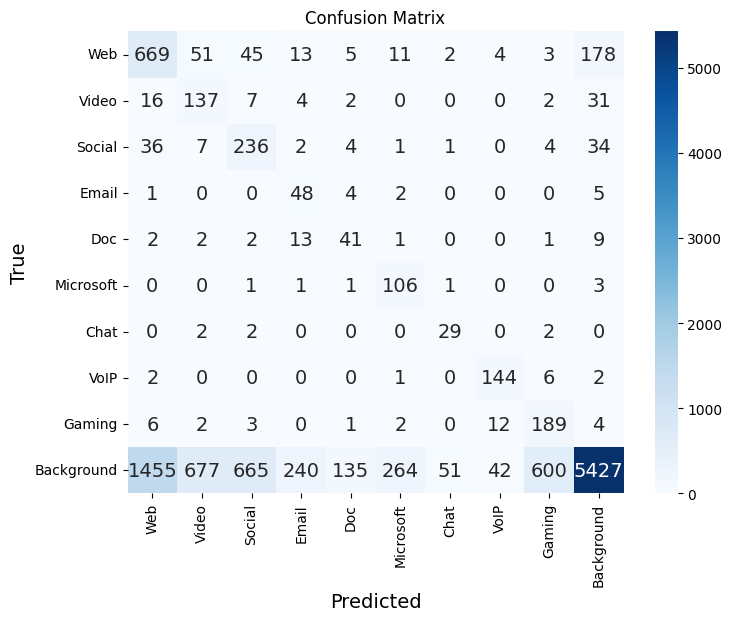

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

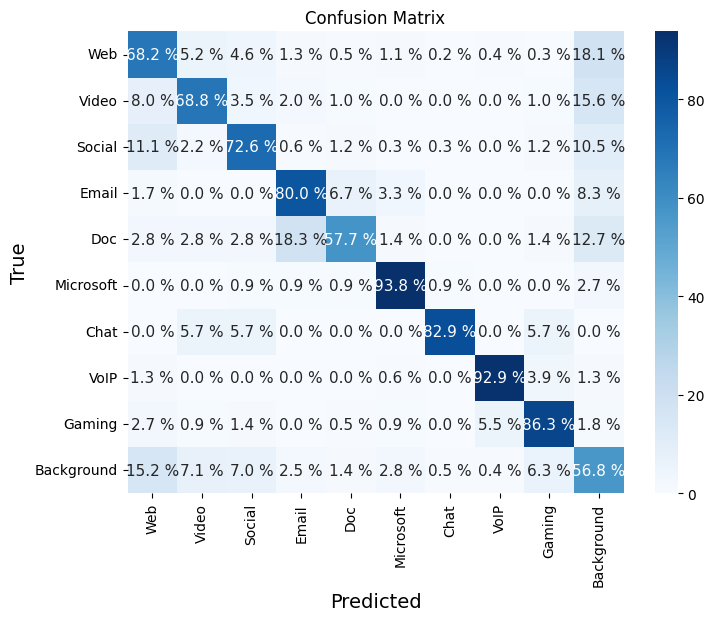

In [36]:
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 11}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrixpercent.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# mask for misclassified samples
mask = (y_pred != y_test)

# pick out the probability that the model assigned to its (wrong) prediction
mis_probs = y_pred_prob[mask, y_pred[mask]]

# plot a histogram of those confidences
plt.figure()
plt.hist(mis_probs, bins=20)
plt.xlabel('Softmax probability of predicted class')
plt.ylabel('Number of misclassified samples')
plt.title('Confidence distribution for misclassified samples')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Select only the misclassified samples
mask = (y_pred != y_test)

# 2) Grab the softmax score assigned to the (wrong) predicted class
mis_probs = y_pred_prob[mask, y_pred[mask]]

# 3) Sort and build the CDF
sorted_probs = np.sort(mis_probs)
cdf = np.arange(1, len(sorted_probs) + 1) / len(sorted_probs)

# 4) Plot
plt.figure()
plt.plot(sorted_probs, cdf)
plt.xlabel('Softmax probability of predicted class')
plt.ylabel('Cumulative proportion')
plt.title('CDF of Softmax Probabilities for Misclassified Samples')
plt.show()

In [59]:
y_pred = np.argmax(y_pred_prob, axis=1)  # shape (N,)

# — Step 1: Compute the “max confidence” per sample — #
# This finds, for each sample i, the highest softmax‐score across all classes.
confidences = np.max(y_pred_prob, axis=1)  # shape: (N,)

# — Step 2: Build a mask for “keep only if max confidence ≥ 0.9” — #
mask_high_conf = confidences >= 0.9  # shape: (N,), dtype=bool

# — Step 3: Filter your arrays by that mask — #
# If you want to keep only rows with confidence ≥ 0.9 in y_pred_prob:
y_pred_prob_filtered = y_pred_prob[mask_high_conf]  # shape: (__ , C)

# If you also want to keep only those predicted‐class indices:
y_pred_filtered = y_pred[mask_high_conf]

In [60]:
y_test_filtered = y_test[mask_high_conf]

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# weighted_accuracy = round(weighted_accuracy(y_test_categorical, y_pred, flow_sizes), 2)
macro_f1 = round(f1_score(y_test_filtered, y_pred_filtered, average='macro'), 2)
accuracy = round(accuracy_score(y_test_filtered, y_pred_filtered), 2)
average_f1 = round(f1_score(y_test_filtered, y_pred_filtered, average='weighted'), 2)
# precision = precision_score(y_test_categorical, y_pred, average=None)
# recall = recall_score(y_test_categorical, y_pred, average=None)
# f1 = f1_score(y_test_categorical, y_pred, average=None)
conf_matrix = confusion_matrix(y_test_filtered, y_pred_filtered)

# Print or use the evaluation metrics as needed
# print(f'Weighted Average Accuracy: {weighted_accuracy}')
print(f'Macro Average F1 Score: {macro_f1}')
print(f'Accuracy: {accuracy}')
print(f'Weighted Average F1 Score: {average_f1}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1 Score: {f1}')
# print(f'Confusion Matrix:\n{conf_matrix}')

Macro Average F1 Score: 0.87
Accuracy: 0.96
Weighted Average F1 Score: 0.96


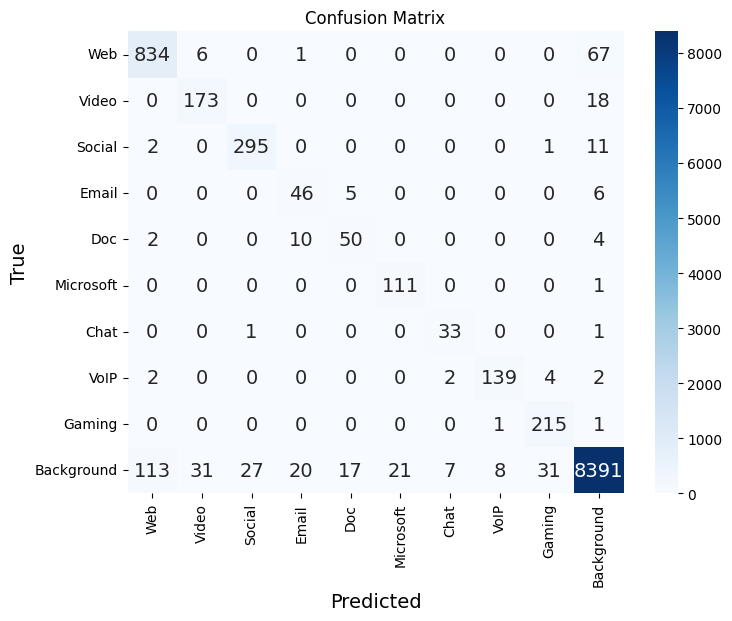

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws={"size": 14})
# ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

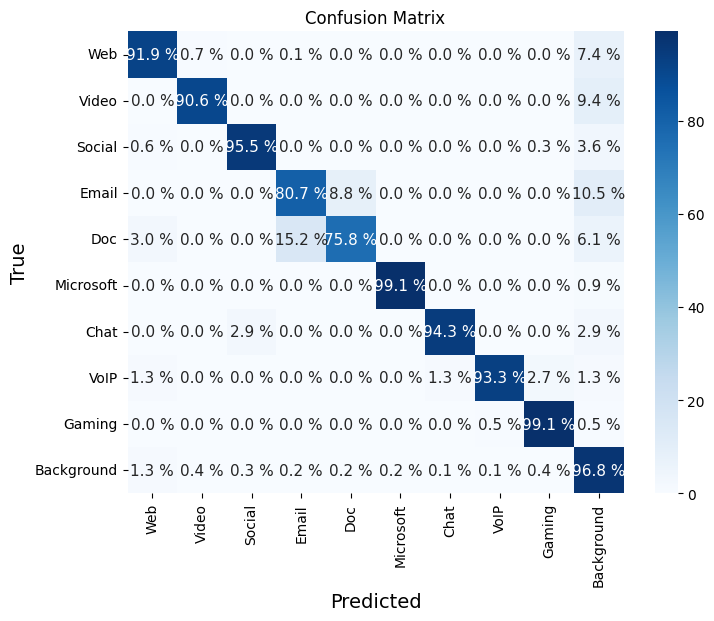

In [63]:
conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

conf_matrix_percentage = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

class_names = ["Web","Video","Social","Email","Doc","Microsoft","Chat","VoIP","Gaming","Background"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
annot_kws = {"size": 11}
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
ax = sns.heatmap(conf_matrix_percentage, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_kws)
for t in ax.texts: t.set_text(t.get_text() + " %")
plt.xlabel('Predicted', fontsize=14)  
plt.ylabel('True', fontsize=14)
plt.title('Confusion Matrix')
plt.savefig('40 >40 confusion_matrixpercent.png', dpi=300, bbox_inches='tight')
plt.show()